#### Analyze the mapping quality of E-MTAB-9543
- **Developed by:** Anna Maguza
- **Affilation:** Faculty of Medicine, Würzburg University
- **Created date:** 4th November, 2024
- **Last modified dte:** 4th November 2024

This notebook is created to check the quality of the mapping from E-MTAB-9543 study. In this notebook we are visualizing `StarSolo` mapping metrics. 

+ Import packages

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import glob

+ Some samples had UMI length 12, and some ten, therefore the mapping script tried both options, and ended up in generation of two Log.progress.out files but one is empty. The following function intends to choose the correct file by analyzing file size.

In [3]:
def get_log_file(sample_dir):
    umi10_log = os.path.join(sample_dir, "UMI10_Log.progress.out")
    umi12_log = os.path.join(sample_dir, "UMI12_Log.progress.out")
    
    if os.path.exists(umi12_log) and os.path.getsize(umi12_log) > 300:
        return umi12_log
    elif os.path.exists(umi10_log) and os.path.getsize(umi10_log) > 300:
        return umi10_log
    else:
        return None

+ Transform Log.progress.out file to dataframe

In [4]:
def process_sample(sample_dir):
    log_file = get_log_file(sample_dir)
    if log_file is None:
        print(f"Warning: No valid mapping log found for sample {os.path.basename(sample_dir)}")
        return None
    
    try:
        # Read the file, skipping the header rows
        df = pd.read_csv(log_file, sep='\s+', skiprows=2,
                        names=['Month', 'Day', 'Time', 'Speed', 'Number', 'Length', 
                              'Mapped_unique', 'Mapped_length', 'Mapped_MMrate', 
                              'Mapped_multi', 'Unmapped_multi+', 'Unmapped_MM', 
                              'Unmapped_short', 'Unmapped_other'])
        
        # Convert percentage columns to float
        percentage_columns = ['Mapped_unique', 'Mapped_MMrate', 'Mapped_multi',
                            'Unmapped_multi+', 'Unmapped_MM', 'Unmapped_short', 
                            'Unmapped_other']
        
        for col in percentage_columns:
            df[col] = df[col].str.rstrip('%').astype('float') / 100.0
        
        # Convert numeric columns
        df['Mapped_length'] = pd.to_numeric(df['Mapped_length'])
        
        # Calculate means for the metrics of interest
        metrics_of_interest = ['Mapped_unique', 'Mapped_length', 'Mapped_MMrate',
                             'Mapped_multi', 'Unmapped_multi+', 'Unmapped_MM',
                             'Unmapped_short', 'Unmapped_other']
        
        mean_values = df[metrics_of_interest].mean()
        return mean_values
        
    except Exception as e:
        print(f"Error processing {log_file}: {str(e)}")
        return None

In [5]:
BASE_DIR = "raw_data/Elmentaite_2021/remapped_adult_data_EMTAB-9543_starsolo"

In [6]:
sample_dirs = glob.glob(os.path.join(BASE_DIR, "*"))
results = {}
for sample_dir in sample_dirs:
    sample_name = os.path.basename(sample_dir)
    print(f"Processing sample: {sample_name}")
        
    mean_values = process_sample(sample_dir)
    if mean_values is not None:
        results[sample_name] = mean_values

Processing sample: Human_colon_16S8159194
Processing sample: Human_colon_16S8000487
Processing sample: Human_colon_16S8000473
Processing sample: Human_colon_16S8123919
Processing sample: Human_colon_16S8001869
Processing sample: Human_colon_16S8001863
Processing sample: Human_colon_16S8002626
Processing sample: Human_colon_16S8000471
Processing sample: Human_colon_16S8000513
Processing sample: Human_colon_16S8001873
Processing sample: Human_colon_16S8117830
Processing sample: Human_colon_16S8117828
Processing sample: Human_colon_16S8123911
Processing sample: Human_colon_16S8002627
Processing sample: Human_colon_16S8123918
Processing sample: Human_colon_16S8000475
Processing sample: Human_colon_16S8000491
Processing sample: Human_colon_16S8123913
Processing sample: Human_colon_16S8001905
Processing sample: Human_colon_16S8001881
Processing sample: Human_colon_16S8002628
Processing sample: Human_colon_16S8123916
Processing sample: Human_colon_16S8000493
Processing sample: Human_colon_16S

In [7]:
results_df = pd.DataFrame(results).T

In [8]:
results_df

,Mapped_unique,Mapped_length,Mapped_MMrate,Mapped_multi,Unmapped_multi+,Unmapped_MM,Unmapped_short,Unmapped_other
Human_colon_16S8159194,0.587353,90.700000,0.003000,0.227824,0.018000,0.0,0.163294,0.003000
Human_colon_16S8000487,0.539889,100.700000,0.004000,0.270111,0.028000,0.0,0.160778,0.001000
Human_colon_16S8000473,0.609121,100.700000,0.004182,0.165303,0.024000,0.0,0.200545,0.001000
Human_colon_16S8123919,0.600217,90.782609,0.003000,0.282043,0.008957,0.0,0.107130,0.002000
Human_colon_16S8001869,0.588000,90.600000,0.004000,0.204750,0.021000,0.0,0.184500,0.002000
...,...,...,...,...,...,...,...,...
Human_colon_16S8123917,0.636444,90.800000,0.002000,0.256667,0.014000,0.0,0.090667,0.002000
Human_colon_16S8002573,0.645000,90.700000,0.002917,0.243167,0.011000,0.0,0.095083,0.005750
Human_colon_16S8000484,0.752000,100.700000,0.004000,0.134000,0.006000,0.0,0.104000,0.004000
Human_colon_16S8002630,0.742231,90.800000,0.002000,0.183923,0.012000,0.0,0.059462,0.002231


In [9]:
output_file = os.path.join(BASE_DIR, "mapping_metrics_summary.csv")
results_df.to_csv(output_file)

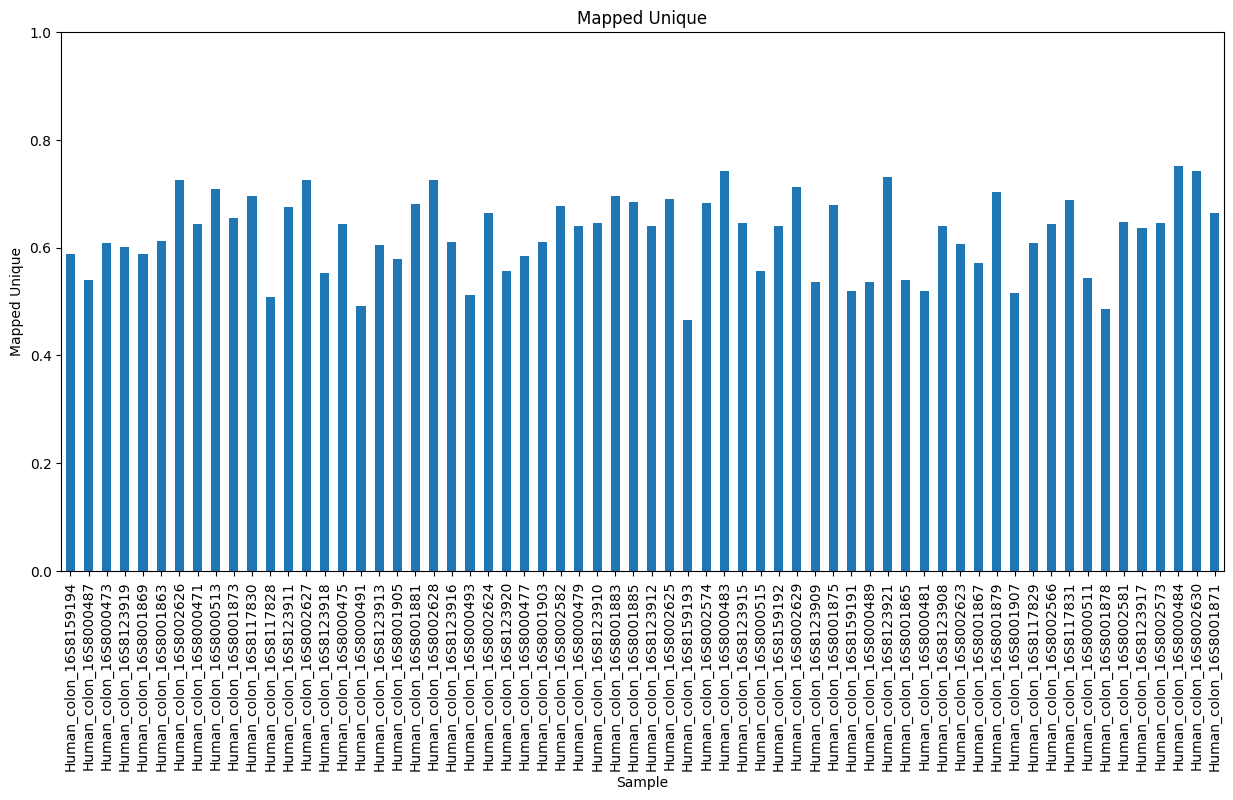

In [10]:
results_df['Mapped_unique'].plot(kind='bar', figsize=(15, 7), title='Mapped Unique')
plt.xlabel('Sample')
plt.ylabel('Mapped Unique')
plt.ylim(0, 1)
plt.xticks(rotation=90)
plt.show()